In [51]:
import pandas as pd, numpy as np, time, json, joblib, warnings
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import randint, uniform
from xgboost import XGBRegressor
warnings.filterwarnings("ignore")
RS = 42

In [52]:
MAKES = {"audi":"Audi", "bmw":"BMW", "ford":"Ford", "hyundi":"Hyundai", "merc":"Mercedes",
         "skoda":"Skoda", "toyota":"Toyota", "vauxhall":"Vauxhall", "vw":"Volkswagen"}

raw = {}
for f, make in MAKES.items():
    d = pd.read_csv(f"{f}.csv")
    raw[make] = d
    print(f"{make:11s} {d.shape[0]:>6,} rows  cols={list(d.columns)}")

Audi        10,668 rows  cols=['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']
BMW         10,781 rows  cols=['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']
Ford        17,965 rows  cols=['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']
Hyundai      4,860 rows  cols=['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax(£)', 'mpg', 'engineSize']
Mercedes    13,119 rows  cols=['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']
Skoda        6,267 rows  cols=['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']
Toyota       6,738 rows  cols=['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']
Vauxhall    13,632 rows  cols=['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']
Volks

In [53]:
audi = raw["Audi"]
display(audi.head())
print(audi.dtypes, "\n")
print("missing:", audi.isna().sum().sum(), "| duplicates:", audi.duplicated().sum())
display(audi.describe())
print("transmission:", audi.transmission.unique())
print("fuelType    :", audi.fuelType.unique())
print("model sample:", [repr(m) for m in audi.model.unique()[:5]])

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0


model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object 

missing: 0 | duplicates: 103


,year,price,mileage,tax,mpg,engineSize
count,10668.000000,10668.000000,10668.000000,10668.000000,10668.000000,10668.000000
mean,2017.100675,22896.685039,24827.244001,126.011436,50.770022,1.930709
std,2.167494,11714.841888,23505.257205,67.170294,12.949782,0.602957
min,1997.000000,1490.000000,1.000000,0.000000,18.900000,0.000000
25%,2016.000000,15130.750000,5968.750000,125.000000,40.900000,1.500000
50%,2017.000000,20200.000000,19000.000000,145.000000,49.600000,2.000000
75%,2019.000000,27990.000000,36464.500000,145.000000,58.900000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,188.300000,6.300000


transmission: ['Manual' 'Automatic' 'Semi-Auto']
fuelType    : ['Petrol' 'Diesel' 'Hybrid']
model sample: ["' A1'", "' A6'", "' A4'", "' A3'", "' Q3'"]


In [54]:
frames = []
for f, make in MAKES.items():
    d = pd.read_csv(f"{f}.csv").rename(columns={"tax(£)": "tax"})
    d["Make"] = make
    frames.append(d)

df = pd.concat(frames, ignore_index=True)
df["model"] = df["model"].str.strip()
df = df.rename(columns={"model":"Model", "year":"Year", "price":"Price",
                        "transmission":"Transmission", "mileage":"Mileage",
                        "fuelType":"FuelType", "tax":"Tax", "mpg":"MPG",
                        "engineSize":"EngineSize"})
df = df[["Make","Model","Year","Transmission","Mileage","FuelType","EngineSize","MPG","Tax","Price"]]

print(f"COMBINED: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())

COMBINED: 99,187 rows x 10 columns


,Make,Model,Year,Transmission,Mileage,FuelType,EngineSize,MPG,Tax,Price
0,Audi,A1,2017,Manual,15735,Petrol,1.4,55.4,150,12500
1,Audi,A6,2016,Automatic,36203,Diesel,2.0,64.2,20,16500
2,Audi,A1,2016,Manual,29946,Petrol,1.4,55.4,30,11000
3,Audi,A4,2017,Automatic,25952,Diesel,2.0,67.3,145,16800
4,Audi,A3,2019,Manual,1998,Petrol,1.0,49.6,145,17300


In [55]:
print("missing values   :", int(df.isna().sum().sum()))
print("duplicate rows   :", int(df.duplicated().sum()))
print("EngineSize == 0  :", int((df.EngineSize == 0).sum()))
print("unique Models:", df.Model.nunique())

missing values   : 0
duplicate rows   : 1475
EngineSize == 0  : 273
unique Models: 195


In [56]:
display(df.describe())

,Year,Mileage,EngineSize,MPG,Tax,Price
count,99187.000000,99187.000000,99187.000000,99187.000000,99187.000000,99187.000000
mean,2017.087723,23058.914213,1.663280,55.166825,120.299838,16805.347656
std,2.123934,21148.523721,0.557646,16.138522,63.150926,9866.773417
min,1970.000000,1.000000,0.000000,0.300000,0.000000,450.000000
25%,2016.000000,7425.000000,1.200000,47.100000,125.000000,9999.000000
50%,2017.000000,17460.000000,1.600000,54.300000,145.000000,14495.000000
75%,2019.000000,32339.000000,2.000000,62.800000,145.000000,20870.000000
max,2060.000000,323000.000000,6.600000,470.800000,580.000000,159999.000000


In [57]:
raw_n = len(df) # data before cleaning

df = df.drop_duplicates().reset_index(drop=True) # dropped duplicates
n = ((df.Year > 2020) | (df.Year < 1997)).sum()
df = df[(df.Year <= 2020) & (df.Year >= 1997)].reset_index(drop=True) # dropped impossible years

n = (df.EngineSize == 0).sum()
df.loc[df.EngineSize == 0, "EngineSize"] = np.nan
df["EngineSize"] = df.EngineSize.fillna(
    df.groupby(["Make","Model"]).EngineSize.transform("median")).fillna(df.EngineSize.median()) 
    # filled missing engine sizes with median of make + model
    
n = (df.MPG <= 10).sum()
df.loc[df.MPG <= 10, "MPG"] = np.nan
df["MPG"] = df.MPG.fillna(
    df.groupby(["Make","Model"]).MPG.transform("median")).fillna(df.MPG.median())
    # filled missng MPG (smaller than 10) with median of make + model
    
hi = df.MPG.quantile(0.995); n = (df.MPG > hi).sum(); df["MPG"] = df.MPG.clip(upper=hi) # handled outliers for MPG by clipping at P99.5
df = df[df.Price >= 500].reset_index(drop=True) # dropped prices under 500 GPB

hi = df.Price.quantile(0.999); n = (df.Price > hi).sum(); df["Price"] = df.Price.clip(upper=hi) 
hi = df.Mileage.quantile(0.999); n = (df.Mileage > hi).sum(); df["Mileage"] = df.Mileage.clip(upper=hi)
# handled outliers for price and mileage by clipping at p99.9

for c in ["Transmission", "FuelType"]:
    df[c] = df[c].str.strip().str.title() # consistent categories

print(f"Cleaned Data: {len(df):,} rows  (removed {raw_n-len(df):,} = {100*(raw_n-len(df))/raw_n:.2f}%)")
df.to_csv("autoworth_clean.csv", index=False)


Cleaned Data: 97,703 rows  (removed 1,484 = 1.50%)


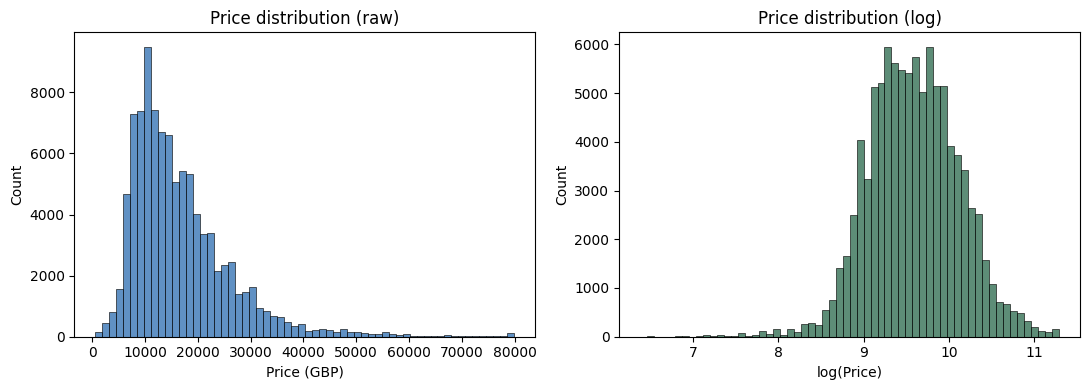

skew raw = 1.90   skew log = -0.08
median GBP 14,472   mean GBP 16,749


In [58]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df.Price, bins=60, ax=ax[0], color="#2b6cb0")
ax[0].set_title("Price distribution (raw)"); ax[0].set_xlabel("Price (GBP)")
sns.histplot(np.log(df.Price), bins=60, ax=ax[1], color="#276749")
ax[1].set_title("Price distribution (log)"); ax[1].set_xlabel("log(Price)")
plt.tight_layout(); plt.show()
print(f"skew raw = {df.Price.skew():.2f}   skew log = {np.log(df.Price).skew():.2f}")
print(f"median GBP {df.Price.median():,.0f}   mean GBP {df.Price.mean():,.0f}")

**Conclusion:** Price is right skewed but by taking log(Price) the skewness gets reduced to 0.08. 
Training should be done on log(Price) to make the model minimize relative error

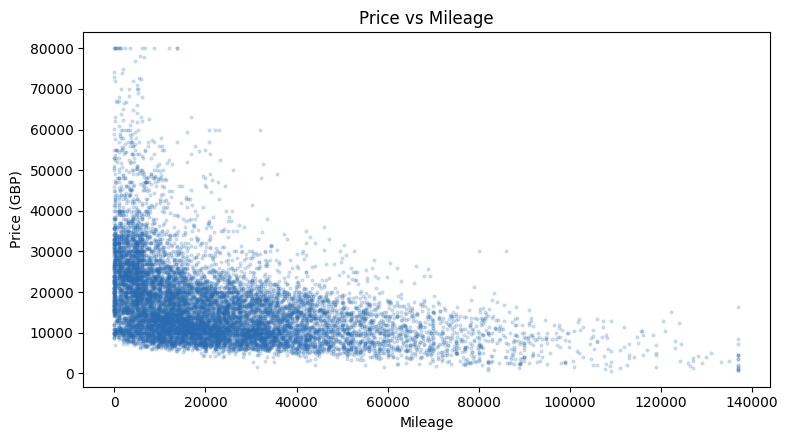

Pearson r = -0.427


In [59]:
fig, ax = plt.subplots(figsize=(8, 4.5))
s = df.sample(12000, random_state=RS)
ax.scatter(s.Mileage, s.Price, s=4, alpha=.18, color="#2b6cb0")
ax.set(xlabel="Mileage", ylabel="Price (GBP)", title="Price vs Mileage")
plt.tight_layout(); plt.show()
print("Pearson r =", round(df.Price.corr(df.Mileage), 3))

**Conclusion:** Price decays strongly at first then flattens (forms a curve rather than a line). A linear model will have to approximate this using a straight line and thus systematically overprice high milage cars, and so tree-based models are expected to beat linear regression's results.

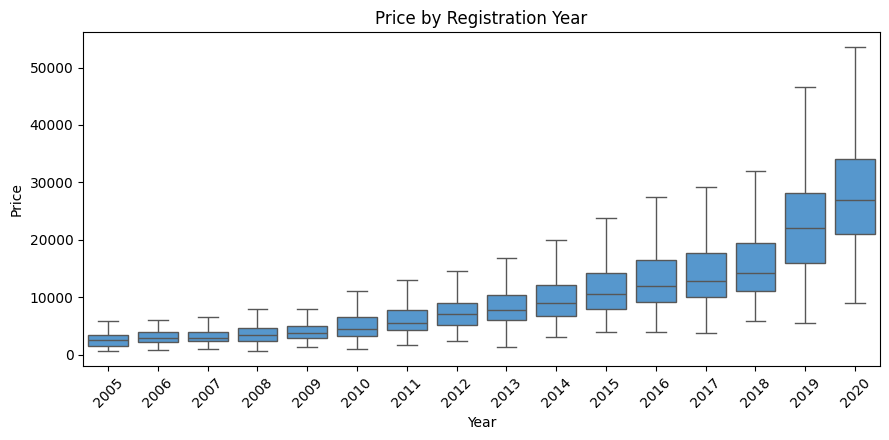

Year
2012     6995.0
2016    11999.0
2019    21990.0
2020    26990.0
Name: Price, dtype: float64


In [60]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=df[df.Year >= 2005], x="Year", y="Price", ax=ax, showfliers=False, color="#4299e1")
ax.set_title("Price by Registration Year"); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()
print(df.groupby("Year").Price.median().loc[[2012, 2016, 2019, 2020]])

**Conclusion:** Price median increases by increasing the year of manufacture which confirms that the year feature will be a top predictor.

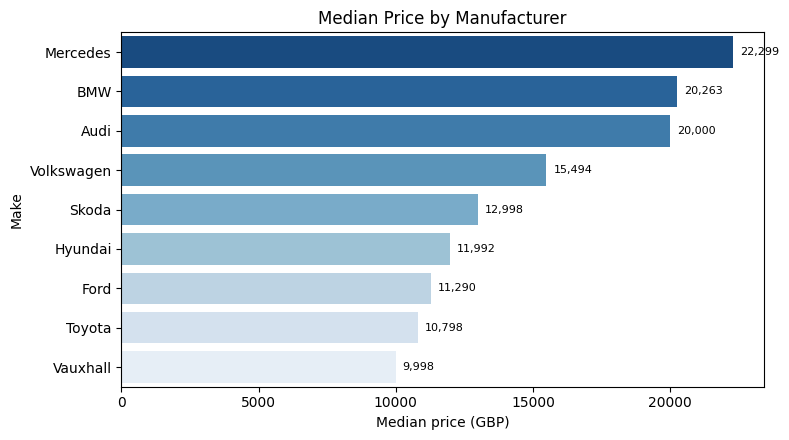

In [61]:
fig, ax = plt.subplots(figsize=(8, 4.5))
o = df.groupby("Make").Price.median().sort_values(ascending=False)
sns.barplot(x=o.values, y=o.index, ax=ax, palette="Blues_r", hue=o.index, legend=False)
ax.set(xlabel="Median price (GBP)", title="Median Price by Manufacturer")
for i, v in enumerate(o.values): ax.text(v+250, i, f"{v:,.0f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

**Conclusion:** Mercedes has the highest median price (£22,299), while Vauxhall has the lowest (£9,998). This shows that car make strongly affects price and should be included in the model.


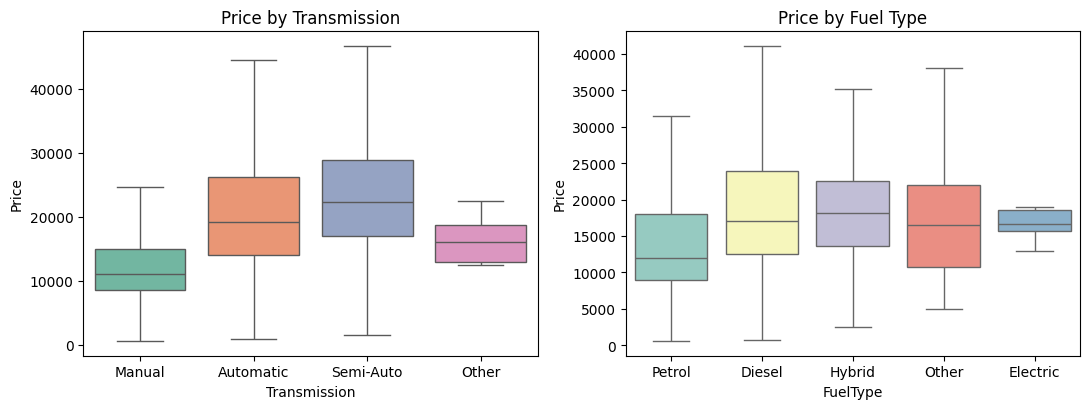

Transmission
Automatic    19245.0
Manual       11000.0
Other        15999.0
Semi-Auto    22250.0
Name: Price, dtype: float64 

FuelType
Diesel      17000.0
Electric    16687.5
Hybrid      18200.0
Other       16450.0
Petrol      11998.0
Name: Price, dtype: float64


In [62]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
sns.boxplot(data=df, x="Transmission", y="Price", ax=ax[0], showfliers=False,
            palette="Set2", hue="Transmission", legend=False)
ax[0].set_title("Price by Transmission")
sns.boxplot(data=df, x="FuelType", y="Price", ax=ax[1], showfliers=False,
            palette="Set3", hue="FuelType", legend=False)
ax[1].set_title("Price by Fuel Type")
plt.tight_layout(); plt.show()
print(df.groupby("Transmission").Price.median(), "\n")
print(df.groupby("FuelType").Price.median())

**Conclusion:** Semi-Auto cars have about twice the median price of Manual cars. This is partly because premium brands often use semi-automatic transmissions. Hybrid and Diesel cars also have higher median prices than Petrol cars.


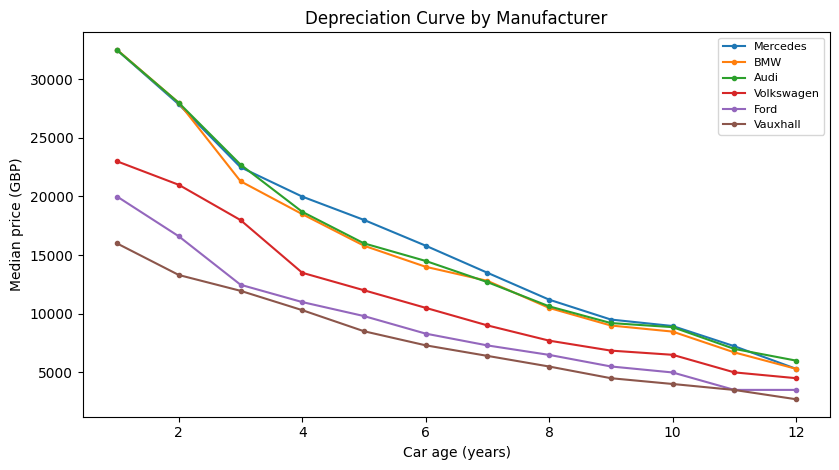

In [63]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
tmp = df.assign(CarAge=2021 - df.Year)
for mk in ["Mercedes","BMW","Audi","Volkswagen","Ford","Vauxhall"]:
    g = tmp[(tmp.Make == mk) & (tmp.CarAge <= 12)].groupby("CarAge").Price.median()
    ax.plot(g.index, g.values, marker="o", ms=3, label=mk)
ax.set(xlabel="Car age (years)", ylabel="Median price (GBP)",
       title="Depreciation Curve by Manufacturer"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Conclusion:** Premium brands lose value faster as cars get older, showing that age and brand are related. This supports using tree-based models, which can capture these interactions better than linear models.

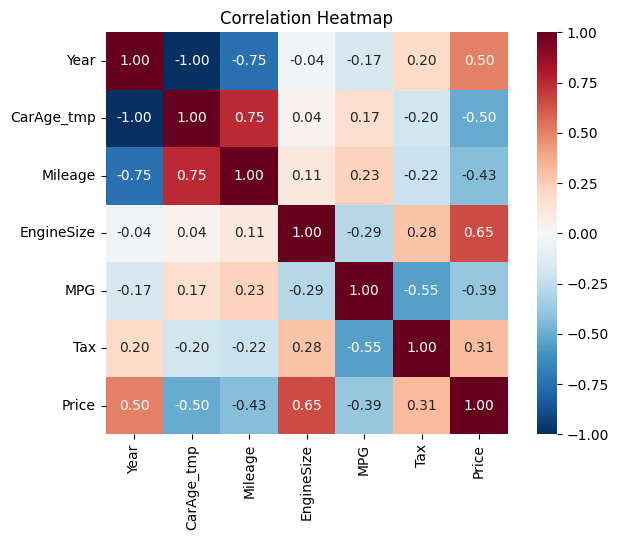

EngineSize    0.649638
CarAge_tmp   -0.504880
Year          0.504880
Mileage      -0.427349
MPG          -0.385443
Tax           0.312652
Name: Price, dtype: float64


In [64]:
df["CarAge_tmp"] = 2021 - df.Year
num = ["Year","CarAge_tmp","Mileage","EngineSize","MPG","Tax","Price"]
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(df[num].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True)
ax.set_title("Correlation Heatmap"); plt.tight_layout(); plt.show()
print(df[num].corr()["Price"].drop("Price").sort_values(key=abs, ascending=False))
df = df.drop(columns=["CarAge_tmp"])

In [65]:
X, y = df.drop(columns=["Price"]), df["Price"]

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=RS)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=RS)

print(f"train      {len(X_tr):>7,}  ({len(X_tr)/len(X):.0%})")
print(f"validation {len(X_val):>7,}  ({len(X_val)/len(X):.0%})")
print(f"test       {len(X_te):>7,}  ({len(X_te)/len(X):.0%})")

train       68,392  (70%)
validation  14,655  (15%)
test        14,656  (15%)


**Feature Engineering:**
I put the feature engineering in a separate .py file to keep the project organized and make sure the same features are created consistently when training the model and when making predictions in the app.
I created four new features:
1. CarAge = (2021 − Year)
Shows how old the car is. I used 2021 because the data was collected in early 2021.
2. MileagePerYear = (Mileage / CarAge)
Shows how much the car is driven each year. This is more useful than total mileage alone because it considers the car's age.
3. PowerProxy = (EngineSize / MPG)
Gives an estimate of the car's performance using engine size and fuel economy, since the dataset does not have horsepower.
4. IsPremium
Marks Audi, BMW, and Mercedes as premium brands. This helps the model capture the clear price difference between premium and non-premium cars.

In [66]:
from features import REFERENCE_YEAR, PREMIUM, NUM, CAT, add_features
display(add_features(X_tr).head())

,Year,Mileage,EngineSize,MPG,Tax,CarAge,MileagePerYear,PowerProxy,IsPremium,Make,Model,Transmission,FuelType
92529,2012,47000,1.2,51.4,125,9,5222.222222,0.023346,0,Volkswagen,Polo,Manual,Petrol
71647,2019,1003,1.4,43.5,145,2,501.500000,0.032184,0,Vauxhall,Corsa,Manual,Petrol
70885,2019,9183,1.4,44.8,150,2,4591.500000,0.031250,0,Vauxhall,Corsa,Manual,Petrol
71869,2019,50,1.4,43.5,145,2,25.000000,0.032184,0,Vauxhall,Corsa,Manual,Petrol
64938,2016,53222,1.5,78.5,0,5,10644.400000,0.019108,0,Toyota,Yaris,Automatic,Hybrid


In [67]:
def make_pipe(model):

    prep = ColumnTransformer([

        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), NUM),

        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]), CAT)
    ])

    inner = Pipeline([
        ("fe", FunctionTransformer(add_features)),
        ("prep", prep),
        ("model", model)
    ])

    return TransformedTargetRegressor(
        regressor=inner,
        func=np.log,
        inverse_func=np.exp
    )


def scores(m, Xs, ys):

    p = m.predict(Xs)

    r2 = r2_score(ys, p)
    mae = mean_absolute_error(ys, p)
    rmse = np.sqrt(mean_squared_error(ys, p))

    return {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }


demo = make_pipe(LinearRegression())
demo.fit(X_tr, y_tr)

X_demo = add_features(X_tr.head())
X_processed = demo.regressor_.named_steps["prep"].transform(X_demo)

print("Feature matrix after preprocessing:",
      X_processed.shape[1], "columns")

Feature matrix after preprocessing: 217 columns


In [68]:
MODELS = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=RS
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=250,
        n_jobs=-1,
        random_state=RS
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        random_state=RS
    ),

    "XGBoost": XGBRegressor(
        n_estimators=600,
        max_depth=7,
        learning_rate=0.07,
        subsample=0.9,
        colsample_bytree=0.9,
        n_jobs=-1,
        random_state=RS,
        tree_method="hist"
    )
}

rows = []
fitted = {}

for name, est in MODELS.items():

    t0 = time.time()

    pipe = make_pipe(est)
    pipe.fit(X_tr, y_tr)

    tr = scores(pipe, X_tr, y_tr)
    va = scores(pipe, X_val, y_val)

    fitted[name] = pipe

    rows.append(
        dict(
            Model=name,
            **{f"Train_{k}": v for k, v in tr.items()},
            **{f"Val_{k}": v for k, v in va.items()},
            Gap=tr["R2"] - va["R2"],
            Seconds=round(time.time() - t0, 1)
        )
    )

    print(
        f"{name:20s} "
        f"valR2={va['R2']:.4f}  "
        f"MAE={va['MAE']:,.0f}  "
        f"({time.time() - t0:.0f}s)"
    )

res = (
    pd.DataFrame(rows)
    .sort_values("Val_R2", ascending=False)
    .reset_index(drop=True)
)

Linear Regression    valR2=0.9325  MAE=1,588  (1s)
Decision Tree        valR2=0.9424  MAE=1,437  (1s)
Random Forest        valR2=0.9645  MAE=1,145  (31s)
Gradient Boosting    valR2=0.9504  MAE=1,380  (179s)
XGBoost              valR2=0.9650  MAE=1,161  (4s)


In [69]:
display(res[["Model","Val_R2","Val_MAE","Val_RMSE","Seconds"]]
        .style.format({"Val_R2":"{:.4f}","Val_MAE":"£{:,.0f}","Val_RMSE":"£{:,.0f}"})
        .background_gradient(subset=["Val_R2"], cmap="Greens"))

,Model,Val_R2,Val_MAE,Val_RMSE,Seconds
0,XGBoost,0.9650,"£1,161","£1,832",4.100000
1,Random Forest,0.9645,"£1,145","£1,844",31.400000
2,Gradient Boosting,0.9504,"£1,380","£2,179",179.200000
3,Decision Tree,0.9424,"£1,437","£2,349",1.000000
4,Linear Regression,0.9325,"£1,588","£2,542",0.700000


**Model Pipeline & Evaluation**

- Created a `make_pipe()` function to:
  - Add the engineered features.
  - Handle missing values.
  - Scale numerical features.
  - Encode categorical features.
  - Apply a log transformation to the target.

- Created a `scores()` function to calculate R², MAE, and RMSE.

- Tested 5 regression models:
  - Linear Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - XGBoost

- Trained and evaluated each model on the training and validation sets.

- Stored the results in a DataFrame and sorted them by validation R² for easy comparison.

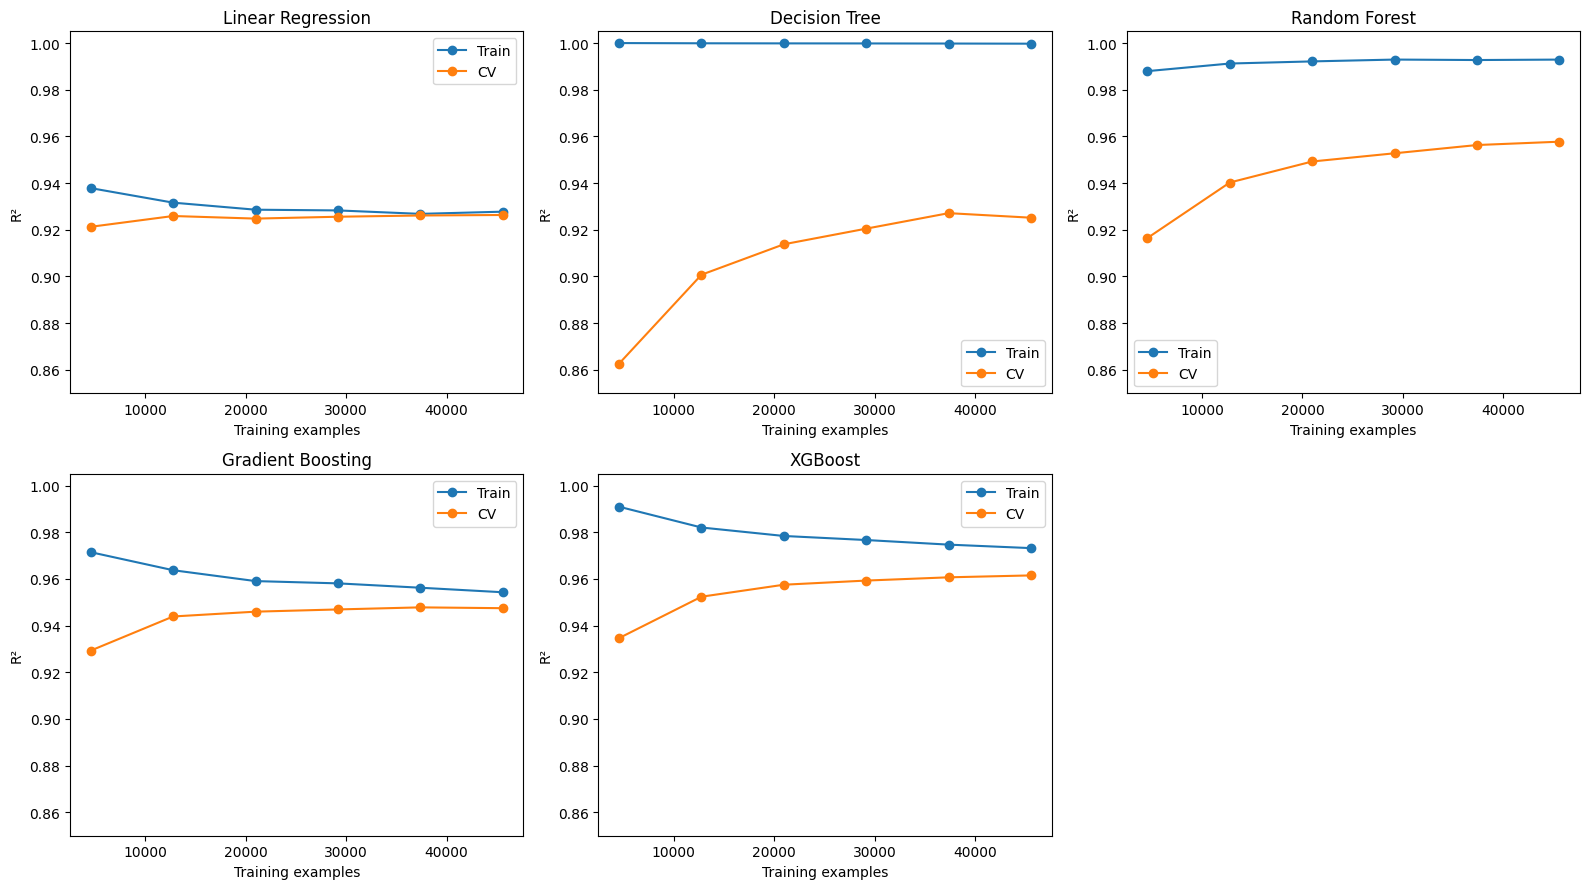

In [70]:
from sklearn.model_selection import learning_curve

train_sizes = np.linspace(0.1, 1.0, 6)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (name, est) in zip(axes, MODELS.items()):

    pipe = make_pipe(est)

    sizes, train_scores, val_scores = learning_curve(
        pipe,
        X_tr,
        y_tr,
        train_sizes=train_sizes,
        cv=3,
        scoring="r2",
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    ax.plot(sizes, train_mean, "o-", label="Train")
    ax.plot(sizes, val_mean, "o-", label="CV")

    ax.set_title(name)
    ax.set_xlabel("Training examples")
    ax.set_ylabel("R²")
    ax.legend()
    ax.set_ylim(0.85, 1.005)

axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [71]:
display(res[["Model","Train_R2","Val_R2","Gap"]]
        .style.format({"Train_R2":"{:.4f}","Val_R2":"{:.4f}","Gap":"{:+.4f}"})
        .background_gradient(subset=["Gap"], cmap="Reds"))

,Model,Train_R2,Val_R2,Gap
0,XGBoost,0.9711,0.9650,+0.0062
1,Random Forest,0.9934,0.9645,+0.0289
2,Gradient Boosting,0.9534,0.9504,+0.0030
3,Decision Tree,0.9996,0.9424,+0.0572
4,Linear Regression,0.9276,0.9325,-0.0049


### Learning Curves

- **Linear Regression:** Train and CV scores are very close, so more data is unlikely to help much. The model is relatively simple.
- **Decision Tree:** Train stays near 1.00 while CV stays around 0.925. This shows clear **overfitting**; limiting tree depth could help.
- **Random Forest:** CV performance keeps improving as more data is added, so more training data may help.
- **Gradient Boosting:** Train and CV scores become very close, showing good generalization and limited benefit from more data.
- **XGBoost:** Train and CV scores also converge at high R², showing strong performance and good generalization.

**Takeaway:** Decision Tree shows the clearest overfitting, while Random Forest may benefit from more data. Gradient Boosting and XGBoost are already performing consistently, so improving the features may be more useful than simply adding more data.

In [72]:
grid = {
    "regressor__model__n_estimators": randint(400, 1200),
    "regressor__model__max_depth": randint(5, 11),
    "regressor__model__learning_rate": uniform(0.03, 0.12),
    "regressor__model__subsample": uniform(0.7, 0.3),
    "regressor__model__colsample_bytree": uniform(0.6, 0.4),
    "regressor__model__min_child_weight": randint(1, 8),
    "regressor__model__reg_lambda": uniform(0.5, 4.0)
}

search = RandomizedSearchCV(
    make_pipe(
        XGBRegressor(
            n_jobs=-1,
            random_state=RS,
            tree_method="hist")),
    grid,
    n_iter=12,
    cv=3,
    scoring="r2",
    random_state=RS,
    n_jobs=1,
    verbose=1
)

search.fit(X_tr, y_tr)
best_params = {}

for k, v in search.best_params_.items():
    best_params[k.split("__")[-1]] = v

print("\nBest parameters:", best_params)

b = scores(fitted["XGBoost"], X_val, y_val)
a = scores(search.best_estimator_, X_val, y_val)

print(
    f"\nBEFORE: R2={b['R2']:.4f}  "
    f"MAE=GBP {b['MAE']:,.0f}  "
    f"RMSE=GBP {b['RMSE']:,.0f}"
)

print(
    f"AFTER:  R2={a['R2']:.4f}  "
    f"MAE=GBP {a['MAE']:,.0f}  "
    f"RMSE=GBP {a['RMSE']:,.0f}"
)

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters: {'colsample_bytree': np.float64(0.6232334448672797), 'learning_rate': np.float64(0.13394113749299222), 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 1061, 'reg_lambda': np.float64(0.725646316108401), 'subsample': np.float64(0.9165996316800473)}

BEFORE: R2=0.9650  MAE=GBP 1,161  RMSE=GBP 1,832
AFTER:  R2=0.9698  MAE=GBP 1,055  RMSE=GBP 1,701


In [75]:
final = make_pipe(XGBRegressor(n_jobs=-1, random_state=RS, tree_method="hist", **best_params))
X_full, y_full = pd.concat([X_tr, X_val]), pd.concat([y_tr, y_val])
final.fit(X_full, y_full)

test = scores(final, X_te, y_te)
pred = final.predict(X_te)
mape = np.mean(np.abs((y_te - pred) / y_te)) * 100

print(f"FINAL TEST ({len(X_te):,} untouched rows)")
print(f"R2   = {test['R2']:.4f}")
print(f"MAE  = GBP {test['MAE']:,.0f}")
print(f"RMSE = GBP {test['RMSE']:,.0f}")
print(f"MAPE = {mape:.2f}%")

FINAL TEST (14,656 untouched rows)
R2   = 0.9717
MAE  = GBP 1,020
RMSE = GBP 1,616
MAPE = 6.38%


### Final Test Results

| Metric   |      Value |
| -------- | ---------: |
| **R²**   | **0.9717** |
| **MAE**  | **£1,020** |
| **RMSE** | **£1,616** |
| **MAPE** |  **6.38%** |


* **Test R² (0.9717) vs Validation R² (0.9698):** The test score is slightly higher because the final model was trained on more data (train + validation). The difference can also come from normal differences between the datasets.
* **MAE vs RMSE:** RMSE (£1,616) is higher than MAE (£1,020), showing that most predictions are close, but some have larger errors.
* **MAPE = 6.38%:** The model is typically within about 6% of the actual car price, which is close to the ±5% Fair Price range used by the deal advisor.



In [76]:

OUT_MODEL = "models/autoworth_model.joblib"
joblib.dump(final, OUT_MODEL)
print("saved:", OUT_MODEL)

saved: /Users/farahemad205/Desktop/Farah/WE Machine Learning/final project/models/autoworth_model.joblib


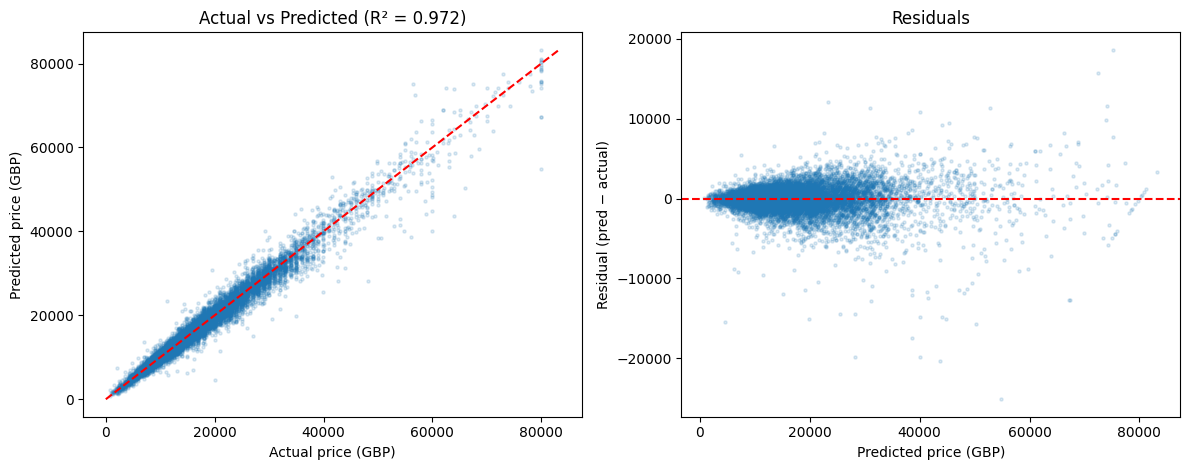

In [77]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))

ax[0].scatter(y_te, pred, s=5, alpha=0.15)
ax[0].plot([0, max(y_te.max(), pred.max())],
           [0, max(y_te.max(), pred.max())], "r--")

ax[0].set_xlabel("Actual price (GBP)")
ax[0].set_ylabel("Predicted price (GBP)")
ax[0].set_title(f"Actual vs Predicted (R² = {test['R2']:.3f})")

ax[1].scatter(pred, pred - y_te, s=5, alpha=0.15)
ax[1].axhline(0, color="r", linestyle="--")

ax[1].set_xlabel("Predicted price (GBP)")
ax[1].set_ylabel("Residual (pred − actual)")
ax[1].set_title("Residuals")

plt.tight_layout()
plt.show()

**Conclusion:** The model systematically underpredicts the expensive cars.

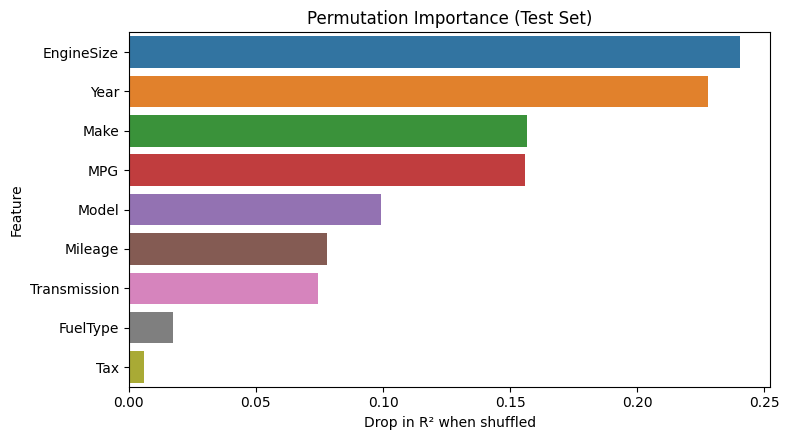

,Feature,R2_drop
6,EngineSize,0.240305
2,Year,0.227943
0,Make,0.156587
7,MPG,0.155640
1,Model,0.099108
4,Mileage,0.077811
3,Transmission,0.074402
5,FuelType,0.017415
8,Tax,0.005940


In [78]:
Xp_base = X_te.sample(6000, random_state=0)
yp = y_te.loc[Xp_base.index]

base_r2 = r2_score(yp, final.predict(Xp_base))

rng = np.random.default_rng(0)
rows = []

for col in Xp_base.columns:

    drops = []

    for _ in range(4):
        Xs = Xp_base.copy()
        Xs[col] = rng.permutation(Xs[col].values)

        drops.append(
            base_r2 - r2_score(yp, final.predict(Xs))
        )

    rows.append((col, np.mean(drops)))

perm = pd.DataFrame(
    rows,
    columns=["Feature", "R2_drop"]
).sort_values("R2_drop", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))

sns.barplot(
    data=perm,
    x="R2_drop",
    y="Feature",
    ax=ax,
    hue="Feature",
    legend=False
)

ax.set(
    xlabel="Drop in R² when shuffled",
    title="Permutation Importance (Test Set)"
)

plt.tight_layout()
plt.show()

display(perm)

**Feature Importance:** EngineSize and Year are the most important features, followed by Make and MPG. Mileage, Model, and Transmission have a moderate effect, while FuelType and especially Tax have a much smaller impact on the model's predictions.


In [79]:
err = X_te.copy()
err["Actual"], err["Predicted"] = y_te.values, pred
err["AbsErr"] = (err.Predicted - err.Actual).abs()
err["PctErr"] = 100 * (err.Predicted - err.Actual) / err.Actual

print("10 largest errors:")
display(err.nlargest(10, "AbsErr")[["Make","Model","Year","Mileage","EngineSize",
                                    "Transmission","FuelType","Actual","Predicted","PctErr"]])

print("\nmedian |%| error by Make:")
print(err.assign(A=err.PctErr.abs()).groupby("Make").A.median().sort_values(ascending=False))

print("\nmedian |%| error by price band:")
print(err.assign(A=err.PctErr.abs(), band=pd.cut(err.Actual, [0, 10000, 20000, 30000, 50000, 100000]))
         .groupby("band", observed=True).A.median())

10 largest errors:


,Make,Model,Year,Mileage,EngineSize,Transmission,FuelType,Actual,Predicted,PctErr
49331,Mercedes,S Class,2016,25317,6.0,Semi-Auto,Petrol,79950.0,54836.289062,-31.411771
53156,Mercedes,E Class,2018,28300,4.0,Automatic,Petrol,63990.0,43705.917969,-31.698831
7142,Audi,A5,2020,2000,3.0,Semi-Auto,Diesel,59995.0,40107.878906,-33.147964
15897,BMW,4 Series,2020,10,2.0,Semi-Auto,Petrol,48155.0,28295.464844,-41.240858
45894,Mercedes,S Class,2019,582,3.0,Automatic,Hybrid,56499.0,75123.281250,32.963913
96022,Volkswagen,Caravelle,2019,17600,2.0,Semi-Auto,Diesel,55990.0,38570.816406,-31.111241
56259,Mercedes,S Class,2019,2931,3.0,Automatic,Hybrid,56890.0,72551.015625,27.528591
7217,Audi,Q7,2019,5000,3.0,Automatic,Diesel,66000.0,50341.441406,-23.725089
69512,Toyota,Land Cruiser,1998,100000,4.2,Manual,Diesel,19990.0,4558.032715,-77.198436
7756,Audi,A6,2018,22000,4.0,Automatic,Petrol,59950.0,44862.609375,-25.166623



median |%| error by Make:
Make
Vauxhall      5.241041
Ford          5.182301
Skoda         5.103466
Audi          5.028520
Hyundai       4.886024
BMW           4.760845
Volkswagen    4.609944
Toyota        4.447396
Mercedes      4.436297
Name: A, dtype: float64

median |%| error by price band:
band
(0, 10000]         5.605426
(10000, 20000]     4.699895
(20000, 30000]     4.555779
(30000, 50000]     4.729594
(50000, 100000]    4.364054
Name: A, dtype: float64


**Conclusion:** The largest errors are mostly recent, expensive, premium cars under-predicted by 24–41%, because the dataset has no trim/spec column to separate a base car from a heavily optioned one. Relative error by Make is fairly flat (4.4%–5.2%), but relative error by price band is actually highest for the cheapest cars and lowest for the most expensive which is the opposite of what the residual plot suggests at a glance, since the same pound error matters far more on a cheap car than an expensive one.

In [80]:
def deal_advisor(model, car: dict, seller_price: float, verbose=True):
    est  = float(model.predict(pd.DataFrame([car]))[0])
    diff = seller_price - est
    pct  = 100 * diff / est

    if   pct < -10: rating = "GREAT DEAL"
    elif pct <  -5: rating = "GOOD DEAL"
    elif pct <=  5: rating = "FAIR PRICE"
    elif pct <= 10: rating = "SLIGHTLY OVERPRICED"
    else:           rating = "OVERPRICED"

    if verbose:
        print(f"Estimated market price : GBP {est:,.0f}")
        print(f"Seller price           : GBP {seller_price:,.0f}")
        print(f"Difference             : GBP {abs(diff):,.0f} {'more' if diff > 0 else 'cheaper'} ({pct:+.1f}%)")
        print(f"Deal rating            : {rating}")
        if abs(diff) < test["MAE"]:
            print(f"  (inside the model's typical error, MAE GBP {test['MAE']:,.0f} -- treat as noise)")

    return {"estimated": est, "seller": seller_price, "difference": diff, "pct": pct, "rating": rating}


car = {"Make": "Audi", "Model": "A4", "Year": 2016, "Transmission": "Automatic",
       "Mileage": 45000, "FuelType": "Diesel", "EngineSize": 2.0, "MPG": 62.8, "Tax": 20}

for asking in [14190, 15530, 16690, 18030, 20030]:
    deal_advisor(final, car, asking)
    print("-" * 52)

Estimated market price : GBP 16,000
Seller price           : GBP 14,190
Difference             : GBP 1,810 cheaper (-11.3%)
Deal rating            : GREAT DEAL
----------------------------------------------------
Estimated market price : GBP 16,000
Seller price           : GBP 15,530
Difference             : GBP 470 cheaper (-2.9%)
Deal rating            : FAIR PRICE
  (inside the model's typical error, MAE GBP 1,020 -- treat as noise)
----------------------------------------------------
Estimated market price : GBP 16,000
Seller price           : GBP 16,690
Difference             : GBP 690 more (+4.3%)
Deal rating            : FAIR PRICE
  (inside the model's typical error, MAE GBP 1,020 -- treat as noise)
----------------------------------------------------
Estimated market price : GBP 16,000
Seller price           : GBP 18,030
Difference             : GBP 2,030 more (+12.7%)
Deal rating            : OVERPRICED
----------------------------------------------------
Estimated market pri

**Example:** Shows how the deal advisor works for a 2016 Audi A4 (estimated GBP 16,000) and rates it from GREAT DEAL at GBP 14,190 (−11.3%) down to OVERPRICED at GBP 20,030 (+25.2%). Prices within the model's own MAE (GBP 1,020) are flagged as noise rather than a real bargain, since the ±5% Fair Price band is close to the model's typical error.